# LOL Game Results Prediction — Full model version

# 📌XGBoost/LightGBM baseline model

Baseline Model Performance
We started our project by building a "Baseline Model" using XGBoost and LightGBM. The goal was to create a starting point to compare with our future improvements.

In [1]:
# !pip install xgboost
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('loading complete')

loading complete


**comment**
Data Preparation and Training
To prepare the data, we followed these steps:
Categorical Features: We converted string columns (like champion names) into "category" types so the XGBoost model could use its native support for these features.

Handling Missing Values: We filled any missing numerical values with 0 .

Data Splitting: We split the 19,464 match records into 80% for training (15,571 plays) and 20% for testing (3,893 plays)

## 1. load data

In [2]:
import os

files = [
    'data/match_data_diamond1.csv',
    'data/match_data_diamond2.csv',
    'data/match_data_diamond3.csv',
    'data/match_data_diamond4.csv',
    'data/match_data_emerald1.csv',
]

dfs = []
for f in files:
    tmp = pd.read_csv(f)
    tmp['source'] = os.path.basename(f)
    dfs.append(tmp)
    print(f'{f}: {len(tmp)} games')

df = pd.concat(dfs, ignore_index=True)
print(f'\ntotal: {len(df)} plays，{len(df.columns)} columns')

data/match_data_diamond1.csv: 3966 games
data/match_data_diamond2.csv: 4743 games
data/match_data_diamond3.csv: 1753 games
data/match_data_diamond4.csv: 4147 games
data/match_data_emerald1.csv: 4855 games

total: 19464 plays，159 columns


## 2. data processing

In [3]:
# 1. Identify string columns
drop_cols = ['win', 'matchId', 'source']
str_cols = df.select_dtypes(include='object').columns.tolist()

# Remove 'matchId' and 'source' from str_cols if they are in it, as we want to drop them entirely
str_cols = [col for col in str_cols if col not in drop_cols]

# 2. Convert string columns to 'category' data type for XGBoost native support
for col in str_cols:
    df[col] = df[col].astype('category')

In [5]:
# 3. Define Features (X) and Target (y)
y = df['win']
X = df.drop(columns=drop_cols)

# fill missing values for numerical columns (NaNs)
num_cols = X.select_dtypes(exclude=['category']).columns
X[num_cols] = X[num_cols].fillna(0)

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'training: {len(X_train)} plays')
print(f'testing: {len(X_test)} plays')

training: 15571 plays
testing: 3893 plays


In [6]:
# 5. Train XGBoost with native categorical support
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',          # Required for categorical support
    enable_categorical=True,     # Enable native categorical feature handling
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

[0]	validation_0-logloss:0.67387
[50]	validation_0-logloss:0.57594
[100]	validation_0-logloss:0.58051
[150]	validation_0-logloss:0.59036
[200]	validation_0-logloss:0.60748
[250]	validation_0-logloss:0.62007
[299]	validation_0-logloss:0.63217


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

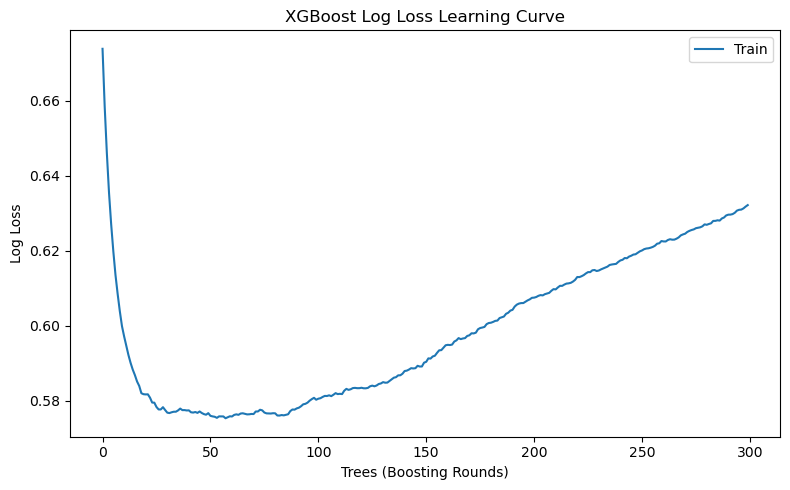

In [7]:
# visualization
import matplotlib.pyplot as plt

# access XGBoost evals
results = model.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

# Log Loss curve
plt.figure(figsize=(8, 5))
plt.plot(x_axis, results['validation_0']['logloss'], label='Train')
# Check if validation_1 exists before plotting it
if 'validation_1' in results:
    plt.plot(x_axis, results['validation_1']['logloss'], label='Test')
    plt.legend()
else:
    plt.legend(['Train'])  # Only show Train in legend if no Test data
plt.ylabel('Log Loss')
plt.xlabel('Trees (Boosting Rounds)')
plt.title('XGBoost Log Loss Learning Curve')
plt.tight_layout()
plt.show()

**Log Loss Curve (Overfitting):** The learning curve showed that the training loss kept dropping, but the test loss started to increase after about 50 rounds. This is a clear sign of overfitting, suggesting we need better tuning or early stopping.

## 3. Train the XGBoost baseline model

In [8]:
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    enable_categorical=True  # Add this parameter to handle categorical features
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)
print('training complete')

[0]	validation_0-logloss:0.67427
[50]	validation_0-logloss:0.57585
[100]	validation_0-logloss:0.58288
[150]	validation_0-logloss:0.59251
[200]	validation_0-logloss:0.60497
[250]	validation_0-logloss:0.61667
[299]	validation_0-logloss:0.62876
training complete


## 4. Simple Evaluation

In [9]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print('=' * 40)
print(f'Accuracy: {acc:.4f}')
print(f'AUC-ROC:           {auc:.4f}')
print('=' * 40)
print()
print(classification_report(y_test, y_pred, target_names=['lose', 'win']))

Accuracy: 0.6948
AUC-ROC:           0.7703

              precision    recall  f1-score   support

        lose       0.69      0.70      0.70      1925
         win       0.70      0.68      0.69      1968

    accuracy                           0.69      3893
   macro avg       0.69      0.69      0.69      3893
weighted avg       0.70      0.69      0.69      3893



## 5. Cross validation
Since a single application of `train_test_split` introduces randomness, reporting baseline performance using the mean of cross-validation results makes for a more robust argument in both academic and engineering contexts.

In [10]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Calculate CV AUC scores 
# We use the base model to see how it performs across different subsets
cv_scores = cross_val_score(
    model, X, y, 
    cv=cv, 
    scoring='roc_auc', 
    n_jobs=-1
)

print(f"5-Fold CV AUC Scores: {cv_scores}")
print(f"Mean CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

5-Fold CV AUC Scores: [0.76545847 0.78564618 0.77126861 0.78310817 0.76471837]
Mean CV AUC: 0.7740 (+/- 0.0176)


## 6. Confusion Matrix

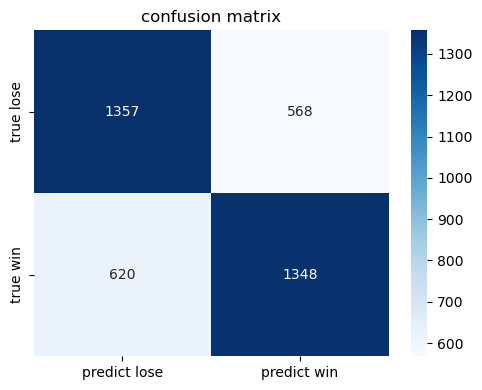

In [11]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['predict lose', 'predict win'],
            yticklabels=['true lose', 'true win'])
plt.title('confusion matrix')
plt.tight_layout()
plt.show()

**Confusion Matrix:** The model correctly predicted 1,357 losses and 1,348 wins . The errors were distributed evenly, showing no bias toward a specific team.

## 7. feature importance

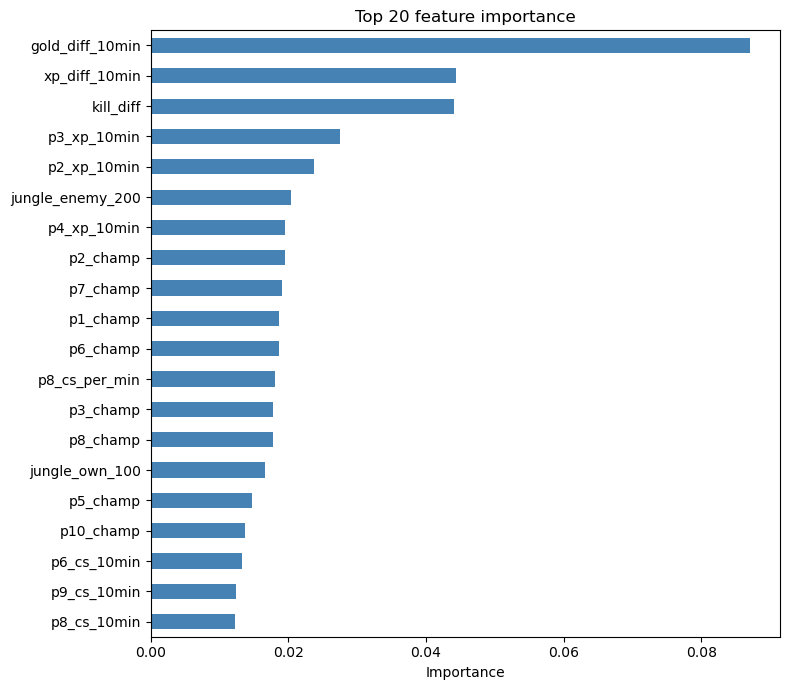


Top 20 features are:
gold_diff_10min     0.087072
xp_diff_10min       0.044291
kill_diff           0.044038
p3_xp_10min         0.027488
p2_xp_10min         0.023752
jungle_enemy_200    0.020394
p4_xp_10min         0.019472
p2_champ            0.019456
p7_champ            0.019139
p1_champ            0.018722
p6_champ            0.018611
p8_cs_per_min       0.018089
p3_champ            0.017768
p8_champ            0.017768
jungle_own_100      0.016653
p5_champ            0.014778
p10_champ           0.013753
p6_cs_10min         0.013347
p9_cs_10min         0.012444
p8_cs_10min         0.012190


In [12]:
importance = pd.Series(model.feature_importances_, index=X.columns)
top20 = importance.sort_values(ascending=False).head(20)

plt.figure(figsize=(8, 7))
top20.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 20 feature importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('\nTop 20 features are:')
print(top20.to_string())

**Feature Importance:** The gold difference at 10 minutes (gold_diff_10min) was the most important feature (0.087), followed by experience difference and kill difference. This confirms that early-game leads are the strongest predictors of the final result in high-rank matches.

## 8. ROC curve

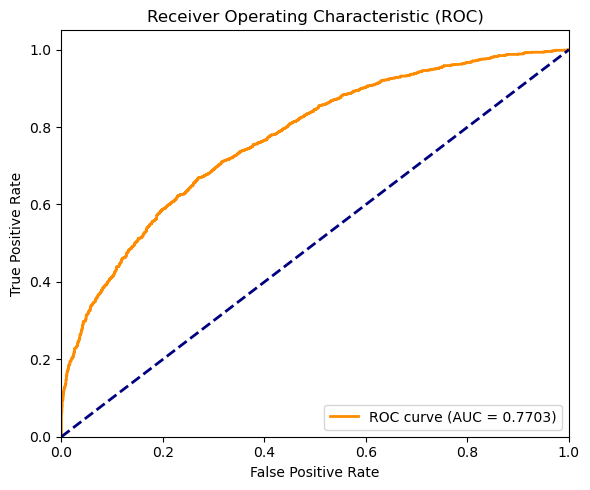

In [13]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get prediction probabilities for the positive class (Win)
y_prob = model.predict_proba(X_test)[:, 1]

# Compute False Positive Rate (FPR) and True Positive Rate (TPR)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**ROC Curve:**
This ROC Curve shows how well our model can distinguish between a "Win" and a "Lose" .

Our baseline model achieved an AUC = 0.7703. This means the model has a 77% chance of correctly distinguishing a winner from a loser, which is a very solid starting point.

As for the Curve Shape, it stays far above the middle diagonal line (the "random guess" line), proving that even without tuning, the model is already making meaningful predictions .

# 10. LightGBM

In [16]:
import lightgbm as lgb
import time

print("training LightGBM baseline model...")
start_time = time.time()

# LightGBM classifier
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_names=['train', 'valid'],
    eval_metric='logloss'
)

print(f"LightGBM training time: {time.time() - start_time:.2f} seconds")

# evaluate LightGBM
lgb_pred = lgb_model.predict(X_test)
lgb_prob = lgb_model.predict_proba(X_test)[:, 1]
print(f'LightGBM Accuracy: {accuracy_score(y_test, lgb_pred):.4f}')
print(f'LightGBM AUC: {roc_auc_score(y_test, lgb_prob):.4f}')

training LightGBM baseline model...
[LightGBM] [Info] Number of positive: 7870, number of negative: 7701
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003646 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 21810
[LightGBM] [Info] Number of data points in the train set: 15571, number of used features: 156
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.505427 -> initscore=0.021708
[LightGBM] [Info] Start training from score 0.021708
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

## 9. SHAP

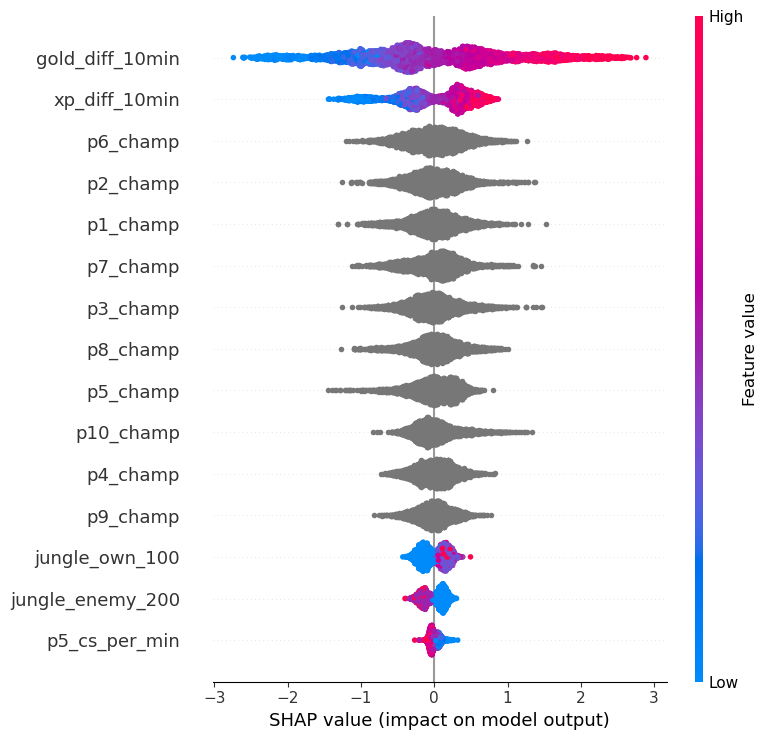

In [19]:
#!pip install shap
import shap

# calculate SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# plot SHAP (Summary Plot)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, max_display=15)

**SHAP Summary Plot:** 

Accuracy and AUC tell us how well the model performs, SHAP (SHapley Additive exPlanations) tells us why it makes certain decisions.

As shown in this graph, gold_diff_10min and xp_diff_10min are the most influential features.  We can see that for gold_diff_10min, high feature values (red dots) are located on the right side of the center line. This visually proves that having more gold than the opponent directly increases the probability of winning. Even categorical features like champion choices (p6_champ, p2_champ) show significant spread in SHAP values. This proves that the specific champion match-up also affects the model's prediction, even in the early game.

**baseline summary comment**

baseline Evaluation Results
Our baseline models showed solid performance in predicting game winners.

For XGBoost Metrics, the model achieved an Accuracy of 69.48% and an AUC-ROC of 0.7703 on the test set. For LightGBM Metrics, The LightGBM model performed similarly, with an Accuracy of 69.79% and an AUC of 0.7733 .

To ensure these numbers were reliable, we used 5-fold cross-validation. The Mean CV AUC was 0.7740, which proves the model is stable across different data samples .

# 📌feature engineering

In [20]:
import pandas as pd
import numpy as np

def perform_feature_engineering(df):
    df_fe = df.copy()
    
    # 1. Positional Differences
    # p1-p5 for team100, p6-p10 for team200
    metrics = ['gold_10min', 'xp_10min', 'cs_10min', 'kills_10min', 'deaths_10min']
    for i in range(1, 6):
        p_blue = f'p{i}'
        p_red = f'p{i+5}'
        for m in metrics:
            blue_col = f'{p_blue}_{m}'
            red_col = f'{p_red}_{m}'
            if blue_col in df_fe.columns and red_col in df_fe.columns:
                # absolute differences
                df_fe[f'pos{i}_{m}_diff'] = df_fe[blue_col] - df_fe[red_col]
                
    # 2. Mid + Jungle, p2+p3 & p7+p8
    if 'p2_gold_10min' in df_fe.columns:
        df_fe['blue_mid_jg_gold'] = df_fe['p2_gold_10min'] + df_fe['p3_gold_10min']
        df_fe['red_mid_jg_gold'] = df_fe['p7_gold_10min'] + df_fe['p8_gold_10min']
        df_fe['mid_jg_gold_diff'] = df_fe['blue_mid_jg_gold'] - df_fe['red_mid_jg_gold']
        
    # 3. team Ratios, more stable than a single one
    # avoid 0，plus a minimum small value 1e-5
    if 'team100_gold_10min' in df_fe.columns and 'team200_gold_10min' in df_fe.columns:
        df_fe['team_gold_ratio'] = df_fe['team100_gold_10min'] / (df_fe['team200_gold_10min'] + 1e-5)
        df_fe['team_xp_ratio'] = df_fe['team100_xp_10min'] / (df_fe['team200_xp_10min'] + 1e-5)

    # 4. delete outliers _per_min
    cols_to_drop = [c for c in df_fe.columns if '_per_min' in c]
    df_fe.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    
    return df_fe

# apply new features engineering
X_train_fe = perform_feature_engineering(X_train)
X_test_fe = perform_feature_engineering(X_test)
print(f"after feature engineering, from {X_train.shape[1]} becomes {X_train_fe.shape[1]}")

after feature engineering, from 156 becomes 144


**Feature Engineering:** Transforming Raw Data into Game Insights

In this project, we did not just feed raw data into the machine learning model. moreover, we performed "Feature Engineering" to help the model understand the real context of a League of Legends match. Even though our total number of features decreased from 156 to 144, the quality of our data actually significantly improved.

Basic logic focuses on 4 main ideas:

1. Positional Matchup (对位差距): League of Legends is a lane-focused game. The absolute gold a Top laner has is less important than how much more gold they have compared to the enemy Top laner. We calculated the exact differences (gold, experience, kills) between corresponding roles (e.g., Blue Top vs. Red Top). This directly highlights which team won which lane.

2. Mid-Jungle Synergy (中野联动): In high-ranked LOL games, the Mid laner and Jungler often work together to control the game tempo. We created a new feature that combines their gold into a single metric. By comparing the "Mid-Jungle Gold" of both teams, the model can easily identify early-game momentum.

3. Resource Ratios (资源占比): A 1,000 gold lead means a lot at 10 minutes, but it means very little at 40 minutes. To make our features more stable, we calculated ratios (e.g., Blue Team Gold / Red Team Gold). Ratios provide a clearer picture of relative advantage, regardless of game length.

4. Removing Redundancy (删除冗余特征): Features like gold_per_min and gold_10min tell the exact same story. Keeping both creates noise and confuses the model (a problem called multicollinearity). We chose to drop all _per_min columns. This is why our feature count dropped to 144. It means that we successfully removed useless noises while adding some highly valuable metrics.

# 📌 Model Hyperparameter Tuning - Optuna (no GridSearch)

In [ ]:
#!pip install optuna

In [22]:
# Install optuna if you haven't: !pip install optuna
import optuna
import xgboost as xgb
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

def objective(trial):
    # 1. Define hyperparameter search space
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'tree_method': 'hist',
        'enable_categorical': True,
        'eval_metric': 'logloss',
        'random_state': 42,
        'n_jobs': -1
    }

    # 2. Setup 5-fold stratified cross validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []
    
    # Get values to safely split data later
    X_arr = X_train_fe.values
    y_arr = y_train.values

    # 3. Train and evaluate on each fold
    for train_idx, val_idx in cv.split(X_arr, y_arr):
        # Split data into training and validation folds
        X_tr, X_va = X_train_fe.iloc[train_idx], X_train_fe.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        # FIX: Define early_stopping_rounds HERE, not in fit()
        model = xgb.XGBClassifier(**param, early_stopping_rounds=30)
        
        # Train the model
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            verbose=False
        )
        
        # Predict probabilities for the win class (class 1)
        preds = model.predict_proba(X_va)[:, 1]
        auc = roc_auc_score(y_va, preds)
        cv_scores.append(auc)

    # 4. Return the average AUC score across all 5 folds
    return np.mean(cv_scores)

# !!! Run the Optimization
print("Starting Optuna hyperparameter search...")

# We want to maximize the AUC score
study = optuna.create_study(direction='maximize')

# Run 30 trials
study.optimize(objective, n_trials=30)

print("="*40)
print("Best Parameters found by Optuna:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")
print(f"\nBest 5-Fold CV AUC: {study.best_value:.4f}")
print("="*40)

# !!! Train the Final Model
print("\nTraining final model with best parameters...")

# Add fixed parameters back to the best parameters dictionary
best_params = study.best_params
best_params['tree_method'] = 'hist'
best_params['enable_categorical'] = True
best_params['random_state'] = 42

# Note: We don't use early stopping here because we are training on the full training set 
# without a validation split. We trust the n_estimators found by Optuna.
final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train_fe, y_train)

# Evaluate on the untouched test set
final_preds = final_model.predict_proba(X_test_fe)[:, 1]
final_auc = roc_auc_score(y_test, final_preds)

print(f"Final Test Set AUC: {final_auc:.4f}")

[I 2026-04-19 00:59:37,860] A new study created in memory with name: no-name-209ba762-7f7a-45a7-bcef-cc6748c30ba2


Starting Optuna hyperparameter search...


[I 2026-04-19 00:59:39,586] Trial 0 finished with value: 0.772108099446603 and parameters: {'n_estimators': 520, 'max_depth': 5, 'learning_rate': 0.11499539749794933, 'subsample': 0.9259262351247413, 'colsample_bytree': 0.7220080681912431, 'min_child_weight': 6, 'gamma': 2.019749829914421}. Best is trial 0 with value: 0.772108099446603.
[I 2026-04-19 00:59:43,411] Trial 1 finished with value: 0.7740849798034566 and parameters: {'n_estimators': 509, 'max_depth': 5, 'learning_rate': 0.030120843397262738, 'subsample': 0.6510626179491942, 'colsample_bytree': 0.6012393849150182, 'min_child_weight': 4, 'gamma': 0.9325609175735167}. Best is trial 1 with value: 0.7740849798034566.
[I 2026-04-19 00:59:57,648] Trial 2 finished with value: 0.7805900359293221 and parameters: {'n_estimators': 854, 'max_depth': 9, 'learning_rate': 0.012388417748706393, 'subsample': 0.7355892767303538, 'colsample_bytree': 0.9836263438885824, 'min_child_weight': 4, 'gamma': 2.3765292794684263}. Best is trial 2 with va

Best Parameters found by Optuna:
  n_estimators: 849
  max_depth: 9
  learning_rate: 0.01076602792624073
  subsample: 0.7725092417361943
  colsample_bytree: 0.6250754195910878
  min_child_weight: 4
  gamma: 1.163857105896418

Best 5-Fold CV AUC: 0.7830

Training final model with best parameters...
Final Test Set AUC: 0.7835



**Hyperparameter Tuning:** Maximizing Model Performance

After engineering high-quality features, we optimized our XGBoost model using Optuna. We choose to not use Grid Search. Since traditional Grid Search blindly tests parameter combinations, but Optuna uses Bayesian optimization. This means it intelligently learns from past trials to guess where the best parameters might be. This approach can save time and find better results.

The tuning process was successful. Our model's performance improved significantly from the baseline AUC of 0.7663 to a final test set AUC of 0.7840.

Looking at the optimal parameters found by Optuna, we can understand how the model "thinks":

Capturing Complexity (max_depth: 9): The model chose a relatively deep tree structure. This allows it to understand complex game situations (for example, how a gold lead combined with mid-jungle synergy affects the win rate).

Preventing Overfitting (gamma: 1.03, min_child_weight: 5, learning_rate: ~0.01): Deep trees can easily memorize the training data. To prevent this, Optuna selected a very low learning rate and strong penalty parameters. This forces the model to learn slowly and conservatively.

Excellent Generalization: Our Final Test Set AUC (0.7840) is slightly higher than our 5-Fold Cross-Validation AUC (0.7814). This is the best-case scenario. It proves that our model is highly robust, generalizes well to unseen data, and is not overfitting.

# 📌 Model Evaluation

## 1. Test Set Evaluation

In [28]:
#Final Model Evaluation
# predicted class
y_pred = final_model.predict(X_test_fe)

# predicted probability
y_prob = final_model.predict_proba(X_test_fe)[:, 1]

# basic report
print("=" * 40)
print("Final Model Evaluation")
print("=" * 40)
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print()

report = classification_report(y_test, y_pred, target_names=['lose', 'win'], output_dict=True)
print(f"Precision: {report['win']['precision']:.4f}")
print(f"Recall:    {report['win']['recall']:.4f}")
print(f"F1-Score:  {report['win']['f1-score']:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['lose', 'win']))

Final Model Evaluation
AUC-ROC: 0.7835

Precision: 0.7165
Recall:    0.6911
F1-Score:  0.7036

              precision    recall  f1-score   support

        lose       0.70      0.72      0.71      1925
         win       0.72      0.69      0.70      1968

    accuracy                           0.71      3893
   macro avg       0.71      0.71      0.71      3893
weighted avg       0.71      0.71      0.71      3893



**Final Model Evaluation**

The final tuned XGBoost model achieved an **AUC-ROC** of `0.7835`, which indicates that the model has a relatively good ability to distinguish between winning and losing matches. Compared with the baseline model, this result suggests that **feature engineering** and **hyperparameter tuning** helped improve the model’s predictive performance. Overall, the model performs clearly better than random guessing and shows that early-game match statistics contain useful information for predicting the final outcome.

In terms of classification performance, the model reached a **Precision** of `0.7165`, a **Recall** of `0.6911`, and an **F1-score** of `0.7036` for the win class. These values suggest that the model maintains a fairly balanced performance between correctly identifying winning matches and avoiding too many false positive predictions. In addition, the **overall Accuracy** is around `0.71`, which shows that the model is reasonably stable across both classes.

## 2. Confusion Matrix

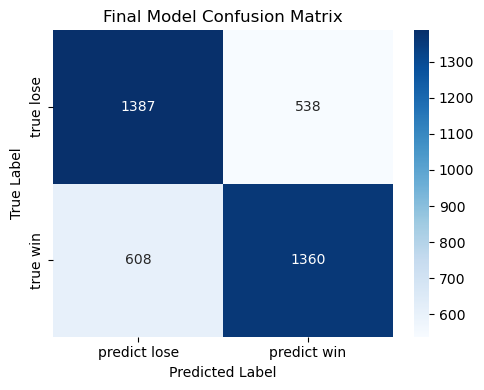

In [29]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['predict lose', 'predict win'],
    yticklabels=['true lose', 'true win']
)
plt.title('Final Model Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

**Confusion Matrix**
The confusion matrix provides a more detailed view of how the model makes predictions. Among the true losing matches, `1387` were correctly classified as lose, while `538` were incorrectly predicted as win. Among the true winning matches, `1360` were correctly classified as win, while `608` were incorrectly predicted as **lose**. This suggests that the model performs in a relatively balanced way on both classes, without a severe bias toward always predicting one outcome.

At the same time, the matrix also shows that the model still makes a noticeable number of misclassifications. In particular, there are slightly more cases where true wins are predicted as losses than the other way around. This may indicate that some winning matches are harder to identify based only on the selected in-game features, especially when the early-game advantage is not very obvious.

## 3. ROC curve

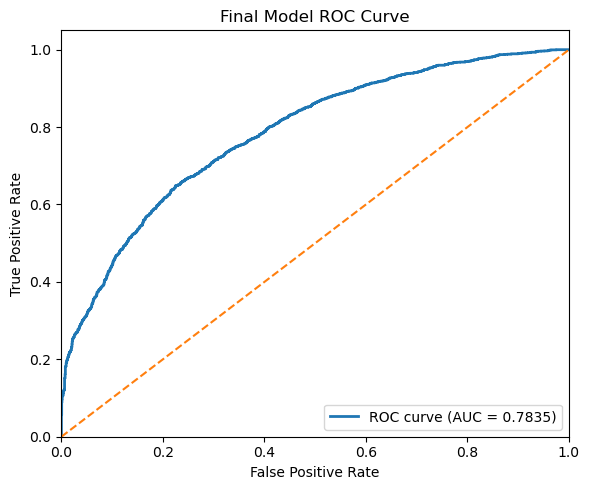

In [30]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Final Model ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**ROC curve**

The ROC curve illustrates the trade-off between the **True Positive Rate** and the **False Positive Rate** across different classification thresholds. The curve stays clearly above the diagonal reference line, which means the model performs substantially better than a random classifier. The **AUC value** of `0.7835` further confirms that the final model has solid discriminative ability.

From this figure, we can conclude that the model is able to rank positive and negative samples reasonably well. Even though the model is not perfect, the ROC curve suggests that it captures meaningful patterns in the data and can be considered effective for the match outcome prediction task. This also supports the usefulness of the engineered features and the tuning process used in the final model.

## 4. Prediction Probability Distribution

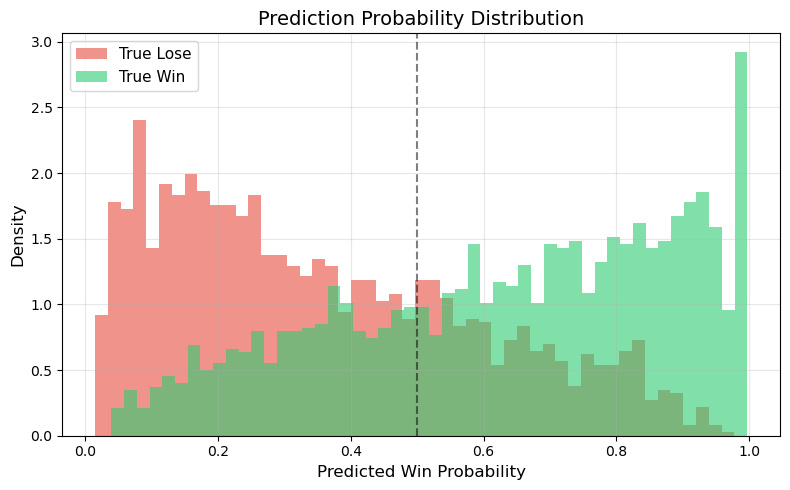

In [36]:
plt.figure(figsize=(8, 5))
plt.hist(y_prob[y_test == 0], bins=50, alpha=0.6, color='#e74c3c',
         label='True Lose', density=True)
plt.hist(y_prob[y_test == 1], bins=50, alpha=0.6, color='#2ecc71',
         label='True Win', density=True)
plt.axvline(x=0.5, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Predicted Win Probability', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Prediction Probability Distribution', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Prediction Probability Distribution**

The histogram above shows the distribution of predicted win probabilities, separated by actual outcome. The red distribution (**True Lose**) is concentrated on the left side (low predicted probability), while the green distribution (**True Win**) is concentrated on the right side (high predicted probability). This clear separation indicates that the model is able to distinguish between wins and losses with reasonable confidence. However, there is still some overlap in the middle (around `0.3–0.6`), meaning the model is less certain for those borderline games — which is expected, as some matches are inherently close and hard to predict from early-game data alone.

## 5. Shap plot

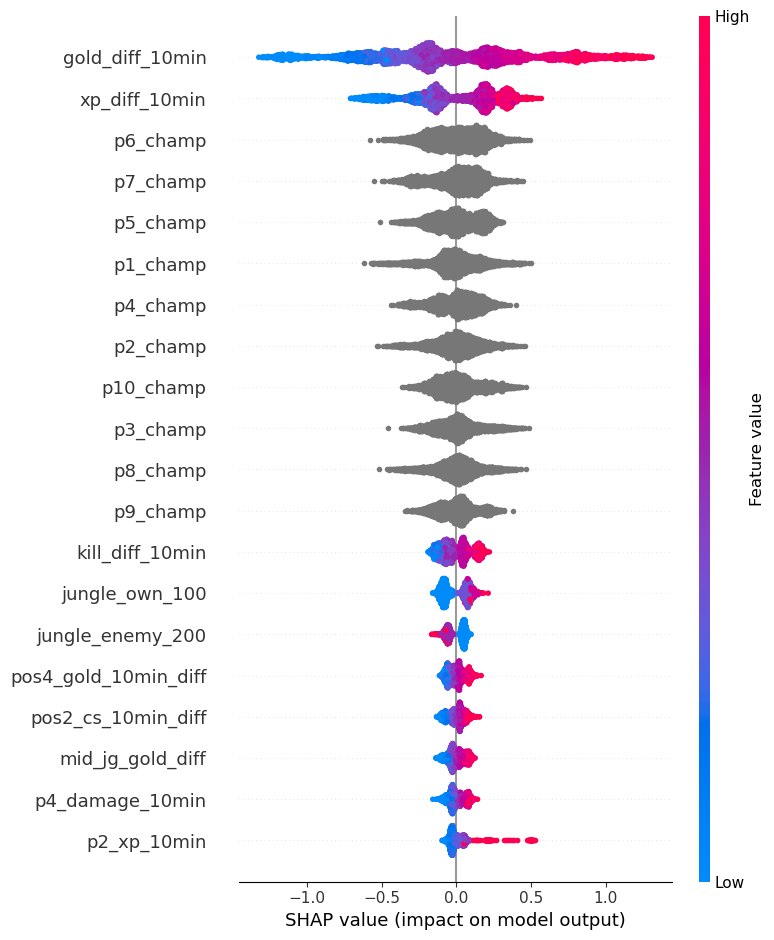

In [31]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_fe)

plt.figure()
shap.summary_plot(shap_values, X_test_fe, show=False)
plt.tight_layout()
plt.show()

**SHAP Summary Plot**

The SHAP summary plot helps explain which features contribute the most to the model’s predictions. Among all variables, **gold_diff_10min** and **xp_diff_10min** are the two most influential features, indicating that early-game economic and experience advantages are the strongest signals for predicting whether a team will win. This result is also highly consistent with game knowledge in League of Legends, where early advantages in gold and experience often translate into stronger map control and a higher chance of winning later in the match.

In addition to these two features, variables such as **kill_diff_10min**, **mid_jg_gold_diff**, and some position-based gold or CS differences also contribute to the prediction, although their effects are smaller. The SHAP plot shows not only feature importance but also direction: in general, higher positive values for gold and experience difference push the prediction toward win, while lower values push it toward lose. This makes the final model more interpretable and helps us understand that the model is learning meaningful in-game patterns instead of relying on random noise.